

# task 1
The MNIST dataset contains 70k small grayscale images (28x280 of handwritten digits from zero to nine and is used in image classification algorithms

no of classes - 10 (from 0 to 9)

image dimensions - 28x28( that is 784 features ranging from 0 which is white to 255 which is black)

train/test split - out of the 70000 60k images are used for training and 10000 are used for testing



In [61]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

In [62]:
from tensorflow.keras.datasets import mnist


(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


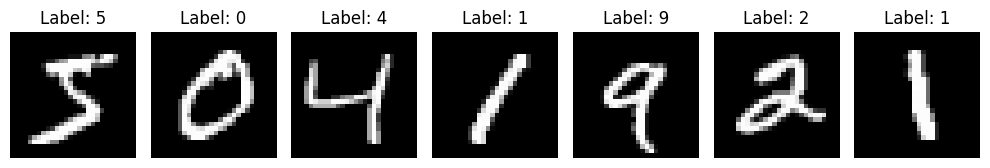

In [63]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 2))

for i in range(7):
    plt.subplot(1, 7, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# task 2
Data Loader acts as the bridge between your dataset and the model and tries to efficiently feed data into the model
1. batching - Dataloader groups multiple images into the batch
2. shuffling - it randomly changes the order of the images in the dataset so that the model doesnt adapt to a order given
3. parallel loading - loading batches together at the same time

the mean and std values were found through research for the mnist dataset

In [64]:
from torchvision import transforms
from torchvision import datasets


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

In [65]:


train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [66]:
'''seperate data loaders for training and testing
since the model doesnt learn from the order because of shuffle we dont need to shuffle while testing '''


from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)



In [67]:
images,labels = next(iter(train_loader))


print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


# task 3

In [68]:
import torch.nn.functional as F

class neural_net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [ ]:
model = neural_net()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 9

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

In [ ]:
print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


parameters are the values that model learns and determine if your model either underfits or overfits the data

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(total_params)

421642
